In [2]:
# 0. Configuration: edit this cell first.
#
# CIFAR-10 version of the single-model reconstruction / t-SNE / perturbation notebook.

MODEL_PATH = "/home/omarg/SIREN_Vista/model_cifar10/vanilla_cifar10/modSiren.pth"
CLASSIFIER_PATH = "/home/omarg/SIREN_Vista/runs/vanilla_cifar10/cifar10_classifier/best_classifier.pth"

DATASET = "cifar10"
DATA_ROOT = "/home/omarg/data"
SPLIT = "test"          # "train" or "test"

# GPU. Set before importing torch in the next cell. After this, the selected
# physical GPU is visible to PyTorch as logical cuda:0.
CUDA_DEVICE_ID = 1
DEVICE = "cuda"         # "cuda" or "cpu"

# Shared inner-loop modulation fitting.
FIT_LR = 0.01

# Random image reconstruction cell.
IMAGE_SEED = 999
RECON_ITERS = [200, 500, 1000, 2000, 5000]

# t-SNE cell.
TSNE_SEED = 0
TSNE_N_SAMPLES = 500
TSNE_FIT_STEPS = 5
TSNE_BATCH_SIZE = 32

# A(x, delta) perturbation cell.
A_SEED = 0
A_N_SAMPLES = 16
A_FIT_STEPS_LIST = [5, 20, 50, 100, 200]
A_EPS_LIST = [1/255, 2/255, 4/255, 8/255, 16/255]
A_BATCH_SIZE = 8

# Model / classifier architecture defaults used if checkpoint metadata is missing.
HIDDEN_DIM = 256
DEPTH = 10
MOD_DIM = 512
CLF_WIDTH = 512
CLF_DEPTH = 3
CLF_DROPOUT = 0.2

print("Configured CIFAR-10 notebook for:")
print("  model     :", MODEL_PATH)
print("  classifier:", CLASSIFIER_PATH)
print("  dataset   :", DATASET, SPLIT)
print("  device    :", DEVICE, "physical GPU", CUDA_DEVICE_ID if DEVICE == "cuda" else "-")

Configured CIFAR-10 notebook for:
  model     : /home/omarg/SIREN_Vista/model_cifar10/vanilla_cifar10/modSiren.pth
  classifier: /home/omarg/SIREN_Vista/runs/vanilla_cifar10/cifar10_classifier/best_classifier.pth
  dataset   : cifar10 test
  device    : cuda physical GPU 1


# CIFAR-10 Single-Model SIREN Diagnostics

This notebook mirrors `model_reconstruction_tsne_perturbation.ipynb`, but is configured for the new CIFAR-10 vanilla SIREN run.

It contains three diagnostics:

1. Pick a random CIFAR-10 image, refit its modulation for several inner-loop budgets, and show reconstruction PSNR.
2. Fit modulations for a subset and plot a 2D t-SNE projection of the modulation vectors with classifier predictions.
3. Compute empirical perturbation amplification `A(x, delta)` over fit budgets and perturbation sizes.

The first cell is only paths and knobs, so you can repoint the notebook at another CIFAR-10 checkpoint later.

## 1. Setup

Imports, repo path setup, CIFAR-10 dataset loading, model loading, classifier loading, and shared fitting helpers. Run these cells after the configuration cell.

In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = str(CUDA_DEVICE_ID)

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

REPO_ROOT = Path("/home/omarg/SIREN_Vista")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from SIREN import ModulatedSIREN
from train_classifier import Classifier
from dataloader import get_cifar10_loader
from evaluate_reconstruction import batched_forward

if DEVICE == "cuda" and not torch.cuda.is_available():
    print("CUDA requested but unavailable; falling back to CPU")
    DEVICE = "cpu"

print("repo root:", REPO_ROOT)
print("torch:", torch.__version__)
if DEVICE == "cuda":
    print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
    print("logical GPU count:", torch.cuda.device_count())
    print("cuda:0:", torch.cuda.get_device_name(0))
print("device:", DEVICE)

repo root: /home/omarg/SIREN_Vista
torch: 2.0.1+cu117
CUDA_VISIBLE_DEVICES: 1
logical GPU count: 1
cuda:0: NVIDIA GeForce RTX 2080 Ti
device: cuda


In [4]:
def load_siren_checkpoint(path):
    """Load CIFAR-10 ModulatedSIREN and return (model, checkpoint_dict)."""
    path = Path(path)
    ckpt = torch.load(path, map_location=DEVICE)
    model_args = ckpt.get("model_args", {}) or {}

    hidden_dim = model_args.get("hidden_dim", HIDDEN_DIM)
    depth = model_args.get("depth", DEPTH)
    mod_dim = model_args.get("mod_dim", MOD_DIM)
    height = model_args.get("height", 32)
    width = model_args.get("width", 32)
    out_features = model_args.get("out_features", 3)

    model = ModulatedSIREN(
        height=height,
        width=width,
        hidden_features=hidden_dim,
        num_layers=depth,
        modul_features=mod_dim,
        device=DEVICE,
        out_features=out_features,
    ).to(DEVICE)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)
    return model, ckpt


def load_classifier_checkpoint(path, mod_dim):
    path = Path(path)
    ckpt = torch.load(path, map_location=DEVICE)
    state = ckpt.get("state_dict", ckpt)
    classifier = Classifier(
        width=CLF_WIDTH,
        depth=CLF_DEPTH,
        in_features=mod_dim,
        num_classes=10,
        dropout=CLF_DROPOUT,
    ).to(DEVICE)
    classifier.load_state_dict(state)
    classifier.eval()
    for p in classifier.parameters():
        p.requires_grad_(False)
    return classifier, ckpt


model, model_ckpt = load_siren_checkpoint(MODEL_PATH)
classifier, classifier_ckpt = load_classifier_checkpoint(CLASSIFIER_PATH, model.modul_features)

loader = get_cifar10_loader(
    root=DATA_ROOT,
    train=(SPLIT == "train"),
    batch_size=1,
    num_workers=0,
    pin_memory=False,
)
dataset = loader.dataset

H = model.height
W = model.width
C = getattr(model, "out_features", 3)

print("Loaded model:")
print("  checkpoint:", MODEL_PATH)
print("  epoch:", model_ckpt.get("epoch"))
print("  loss:", model_ckpt.get("loss"))
print("  variant:", model_ckpt.get("variant"))
print("  model_args:", model_ckpt.get("model_args"))
print("  height, width, channels:", H, W, C)
print("  modul_features:", model.modul_features)
print("Loaded classifier:", CLASSIFIER_PATH)
print("Loaded dataset:", DATASET, SPLIT, "n=", len(dataset))

/home/omarg/miniforge3/envs/pss/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Files already downloaded and verified
Loaded model:
  checkpoint: /home/omarg/SIREN_Vista/model_cifar10/vanilla_cifar10/modSiren.pth
  epoch: 4
  loss: 0.0182130315562572
  variant: vanilla
  model_args: {'dataset': 'cifar10', 'hidden_dim': 256, 'mod_dim': 512, 'depth': 10, 'height': 32, 'width': 32, 'out_features': 3}
  height, width, channels: 32 32 3
  modul_features: 512
Loaded classifier: /home/omarg/SIREN_Vista/runs/vanilla_cifar10/cifar10_classifier/best_classifier.pth
Loaded dataset: cifar10 test n= 10000


In [5]:
CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]


def psnr_from_mse(mse):
    mse = torch.as_tensor(mse).clamp_min(1e-12)
    return 10.0 * torch.log10(1.0 / mse)


def image_to_target(image):
    """Convert (3,H,W) CIFAR image to SIREN target shape (H*W, 3)."""
    return image.to(DEVICE).float().permute(1, 2, 0).reshape(-1, image.shape[0])


def target_to_image(target_flat):
    """Convert SIREN output shape (H*W, 3) to display image (H,W,3)."""
    return target_flat.detach().view(H, W, C).clamp(0, 1).cpu().numpy()


def show_cifar(ax, image_chw, title=None):
    img = image_chw.detach().cpu().permute(1, 2, 0).clamp(0, 1).numpy()
    ax.imshow(img)
    if title is not None:
        ax.set_title(title)
    ax.axis("off")


def fit_phi_snapshots(model, image_chw, iter_checkpoints, lr=0.01):
    """Fit one modulation vector and save RGB reconstructions at selected steps."""
    checkpoints = sorted(set(int(x) for x in iter_checkpoints))
    max_iter = max(checkpoints)
    target = image_to_target(image_chw)
    phi = torch.zeros(model.modul_features, device=DEVICE, requires_grad=True)
    opt = optim.SGD([phi], lr=lr)
    snapshots = {}

    for step in range(1, max_iter + 1):
        opt.zero_grad()
        fitted = model(phi)
        loss = ((fitted - target) ** 2).mean()
        loss.backward()
        opt.step()

        if step in checkpoints:
            with torch.no_grad():
                fitted_post = model(phi).detach()
                mse = ((fitted_post - target) ** 2).mean()
                snapshots[step] = {
                    "phi": phi.detach().clone(),
                    "fitted_flat": fitted_post.detach().clone(),
                    "mse": float(mse.item()),
                    "psnr": float(psnr_from_mse(mse).item()),
                }
    return snapshots


def batched_fit_phi(model, images_chw, steps, lr=0.01):
    """Fit modulations for a batch of CIFAR images in parallel.

    images_chw: (B,3,H,W) tensor in [0, 1]
    returns: phi_batch (B, mod_dim), mse_per (B,)
    """
    images_chw = images_chw.to(DEVICE).float()
    B = images_chw.shape[0]
    target = images_chw.permute(0, 2, 3, 1).reshape(B, -1, images_chw.shape[1])
    phi = torch.zeros(B, model.modul_features, device=DEVICE, requires_grad=True)
    opt = optim.SGD([phi], lr=lr)
    for _ in range(int(steps)):
        opt.zero_grad()
        fitted = batched_forward(model, phi)
        per_image = ((fitted - target) ** 2).mean(dim=(1, 2))
        per_image.sum().backward()
        opt.step()
    with torch.no_grad():
        fitted = batched_forward(model, phi)
        mse = ((fitted - target) ** 2).mean(dim=(1, 2))
    return phi.detach(), mse.detach()


def get_dataset_item(idx):
    image, label = dataset[int(idx)]
    return image.float(), int(label)


def collect_random_images(n, seed):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(dataset), size=int(n), replace=False)
    images, labels = [], []
    for idx in idxs:
        image, label = get_dataset_item(idx)
        images.append(image)
        labels.append(label)
    return torch.stack(images, dim=0), torch.tensor(labels, dtype=torch.long), idxs

print("CIFAR-10 helpers ready.")

CIFAR-10 helpers ready.


## 2. Random CIFAR-10 Image Reconstruction vs Inner Iterations

This cell uses `IMAGE_SEED` to choose one random image from the configured split. It refits the modulation vector from zero and saves RGB reconstructions at `RECON_ITERS`.

Outputs:

- A table with MSE and PSNR for every iteration count.
- A plot showing the original image and every reconstruction, with PSNR in each title.

,dataset_index,label,class_name,iters,mse,psnr
0,8138,1,automobile,200,0.018272,17.382090
1,8138,1,automobile,500,0.016047,17.946142
2,8138,1,automobile,1000,0.014450,18.401321
3,8138,1,automobile,2000,0.013500,18.696760
4,8138,1,automobile,5000,0.012264,19.113737


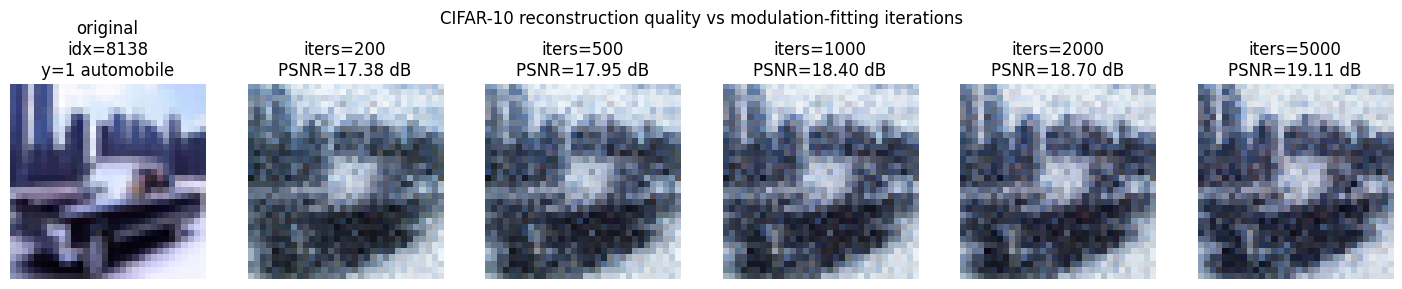

In [19]:
rng = np.random.default_rng(IMAGE_SEED)
image_idx = int(rng.integers(0, len(dataset)))
image, label = get_dataset_item(image_idx)

snapshots = fit_phi_snapshots(model, image, RECON_ITERS, lr=FIT_LR)

rows = []
for it in sorted(snapshots):
    rows.append({
        "dataset_index": image_idx,
        "label": label,
        "class_name": CIFAR10_CLASSES[label],
        "iters": it,
        "mse": snapshots[it]["mse"],
        "psnr": snapshots[it]["psnr"],
    })
recon_df = pd.DataFrame(rows)
display(recon_df)

# Plot original + reconstructions.
n_cols = len(RECON_ITERS) + 1
fig, axes = plt.subplots(1, n_cols, figsize=(2.4 * n_cols, 2.9))
show_cifar(axes[0], image, title=f"original\nidx={image_idx}\ny={label} {CIFAR10_CLASSES[label]}")

for ax, it in zip(axes[1:], sorted(snapshots)):
    recon = target_to_image(snapshots[it]["fitted_flat"])
    ax.imshow(recon)
    ax.set_title(f"iters={it}\nPSNR={snapshots[it]['psnr']:.2f} dB")
    ax.axis("off")

fig.suptitle("CIFAR-10 reconstruction quality vs modulation-fitting iterations")
plt.tight_layout()
plt.show()

## 2b. Reconstruction — stronger vanilla (from `run_vanilla_cifar10_big.sh`)

Same diagnostic as above, but loads the **larger** backbone trained by `scripts/run_vanilla_cifar10_big.sh`:

- `hidden_dim=512`, `mod_dim=1024`, `depth=10`, meta-epochs `8`, functaset inner steps `50`.

Checkpoint path matches the script’s `SLUG`:

`vanilla_cifar10_h512_md1024_d10_e8_make50`

Edit `BIG_MODEL_PATH` if you change `EPOCHS` or `MAKESET_ITERS` in the shell script.

Loaded big model from: /home/omarg/SIREN_Vista/model_cifar10/vanilla_cifar10_h512_md1024_d10_e8_make50/modSiren.pth
  checkpoint epoch: 7 loss: 0.026943405963899686
  model_args: {'dataset': 'cifar10', 'hidden_dim': 512, 'mod_dim': 1024, 'depth': 10, 'height': 32, 'width': 32, 'out_features': 3}


,dataset_index,label,class_name,iters,mse,psnr
0,8138,1,automobile,200,0.045764,13.394784
1,8138,1,automobile,500,0.036237,14.408455
2,8138,1,automobile,1000,0.030909,15.099162
3,8138,1,automobile,2000,0.023087,16.366381
4,8138,1,automobile,5000,0.023102,16.363562


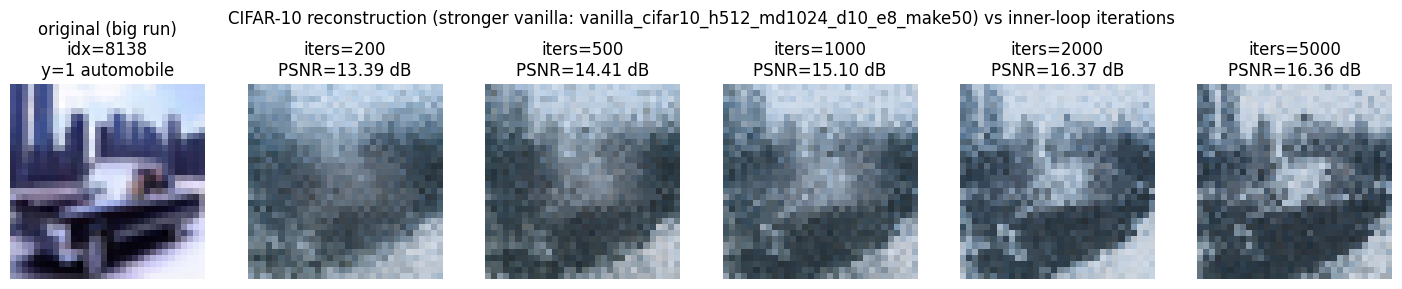

In [8]:
# Stronger vanilla run (must match run_vanilla_cifar10_big.sh SLUG when EPOCHS=8, MAKESET_ITERS=50).
BIG_SLUG = "vanilla_cifar10_h512_md1024_d10_e8_make50"
BIG_MODEL_PATH = f"/home/omarg/SIREN_Vista/model_cifar10/{BIG_SLUG}/modSiren.pth"

# Use the same random image as section 2 for a direct comparison, or set BIG_IMAGE_SEED = None
# to reuse IMAGE_SEED from the config cell.
BIG_IMAGE_SEED = IMAGE_SEED

model_big, ckpt_big = load_siren_checkpoint(BIG_MODEL_PATH)
Hb, Wb, Cb = model_big.height, model_big.width, getattr(model_big, "out_features", 3)

print("Loaded big model from:", BIG_MODEL_PATH)
print("  checkpoint epoch:", ckpt_big.get("epoch"), "loss:", ckpt_big.get("loss"))
print("  model_args:", ckpt_big.get("model_args"))


def target_to_image_big(target_flat):
    return target_flat.detach().view(Hb, Wb, Cb).clamp(0, 1).cpu().numpy()


rng_b = np.random.default_rng(BIG_IMAGE_SEED)
image_idx_b = int(rng_b.integers(0, len(dataset)))
image_b, label_b = get_dataset_item(image_idx_b)

snapshots_big = fit_phi_snapshots(model_big, image_b, RECON_ITERS, lr=FIT_LR)

rows_b = []
for it in sorted(snapshots_big):
    rows_b.append({
        "dataset_index": image_idx_b,
        "label": label_b,
        "class_name": CIFAR10_CLASSES[label_b],
        "iters": it,
        "mse": snapshots_big[it]["mse"],
        "psnr": snapshots_big[it]["psnr"],
    })
recon_df_big = pd.DataFrame(rows_b)
display(recon_df_big)

n_cols_b = len(RECON_ITERS) + 1
fig_b, axes_b = plt.subplots(1, n_cols_b, figsize=(2.4 * n_cols_b, 2.9))
show_cifar(
    axes_b[0],
    image_b,
    title=f"original (big run)\nidx={image_idx_b}\ny={label_b} {CIFAR10_CLASSES[label_b]}",
)

for ax, it in zip(axes_b[1:], sorted(snapshots_big)):
    recon_b = target_to_image_big(snapshots_big[it]["fitted_flat"])
    ax.imshow(recon_b)
    ax.set_title(f"iters={it}\nPSNR={snapshots_big[it]['psnr']:.2f} dB")
    ax.axis("off")

fig_b.suptitle(
    f"CIFAR-10 reconstruction (stronger vanilla: {BIG_SLUG}) vs inner-loop iterations"
)
plt.tight_layout()
plt.show()

## 3. t-SNE of CIFAR-10 Fitted Modulation Vectors

This section fits `TSNE_N_SAMPLES` modulation vectors using `TSNE_FIT_STEPS` inner steps, feeds them to the classifier, then projects the modulation vectors to 2D with t-SNE.

The left plot is colored by true CIFAR-10 class; the right plot is colored by classifier prediction. Wrong predictions are marked with black `x` symbols.

In [15]:
def fit_modulations_for_tsne(n_samples, seed, fit_steps, batch_size):
    images, labels, idxs = collect_random_images(n_samples, seed)
    phis, mses = [], []
    for start in range(0, images.shape[0], batch_size):
        chunk = images[start:start + batch_size]
        phi, mse = batched_fit_phi(model, chunk, steps=fit_steps, lr=FIT_LR)
        phis.append(phi.cpu())
        mses.append(mse.cpu())
    phis = torch.cat(phis, dim=0)
    mses = torch.cat(mses, dim=0)
    return images, labels, idxs, phis, mses

images_tsne, labels_tsne, idxs_tsne, phis_tsne, mses_tsne = fit_modulations_for_tsne(
    TSNE_N_SAMPLES,
    TSNE_SEED,
    TSNE_FIT_STEPS,
    TSNE_BATCH_SIZE,
)

with torch.no_grad():
    logits = classifier(phis_tsne.to(DEVICE))
    pred_tsne = logits.argmax(dim=1).cpu()
    conf_tsne = logits.softmax(dim=1).max(dim=1).values.cpu()

acc = (pred_tsne == labels_tsne).float().mean().item()
print(f"Fitted {len(phis_tsne)} modulations with {TSNE_FIT_STEPS} inner steps")
print(f"Classifier accuracy on this subset: {acc:.4f}")
print(f"Mean reconstruction MSE at {TSNE_FIT_STEPS} steps: {mses_tsne.mean().item():.5f}")

Fitted 500 modulations with 5 inner steps
Classifier accuracy on this subset: 0.4320
Mean reconstruction MSE at 5 steps: 0.01560


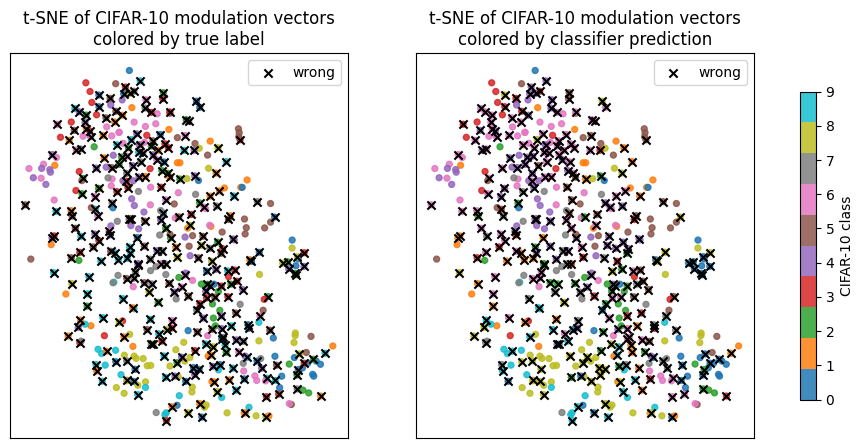

,dataset_index,true_label,true_class,pred_label,pred_class,correct,confidence,mse_fit,z0,z1
0,9527,6,frog,5,dog,False,0.485514,0.008234,-0.207797,6.392075
1,8229,8,ship,1,automobile,False,0.425271,0.032100,-8.763365,-2.662316
2,1453,5,dog,4,deer,False,0.299740,0.016448,-5.132725,9.884121
3,3492,9,truck,6,frog,False,0.449147,0.032665,-7.333548,-3.778966
4,9793,2,bird,8,ship,False,0.444913,0.017973,0.816645,-11.227873
5,6225,3,cat,6,frog,False,0.589996,0.011073,10.060893,-14.624294
6,9728,2,bird,6,frog,False,0.283690,0.006824,-7.448427,15.562420
7,2132,2,bird,6,frog,False,0.549948,0.013316,-3.607226,12.028915
8,1292,4,deer,6,frog,False,0.451776,0.010954,-10.523714,11.294215
9,6662,6,frog,4,deer,False,0.438039,0.007454,3.283040,5.591534


In [16]:
# Compute t-SNE. If sklearn is unavailable, fall back to a simple PCA projection.
try:
    from sklearn.manifold import TSNE
    projector_name = "t-SNE"
    perplexity = min(30, max(5, (len(phis_tsne) - 1) // 3))
    embedding = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=TSNE_SEED,
    ).fit_transform(phis_tsne.numpy())
except Exception as exc:
    print("t-SNE failed or sklearn is unavailable; falling back to PCA.")
    print("Reason:", repr(exc))
    projector_name = "PCA fallback"
    X = phis_tsne.numpy()
    X = X - X.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    embedding = X @ Vt[:2].T

wrong = (pred_tsne != labels_tsne).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc0 = axes[0].scatter(embedding[:, 0], embedding[:, 1], c=labels_tsne.numpy(), cmap="tab10", s=18, alpha=0.85)
axes[0].scatter(embedding[wrong, 0], embedding[wrong, 1], marker="x", c="black", s=35, label="wrong")
axes[0].set_title(f"{projector_name} of CIFAR-10 modulation vectors\ncolored by true label")
axes[0].set_xticks([]); axes[0].set_yticks([])
axes[0].legend(loc="best")

sc1 = axes[1].scatter(embedding[:, 0], embedding[:, 1], c=pred_tsne.numpy(), cmap="tab10", s=18, alpha=0.85)
axes[1].scatter(embedding[wrong, 0], embedding[wrong, 1], marker="x", c="black", s=35, label="wrong")
axes[1].set_title(f"{projector_name} of CIFAR-10 modulation vectors\ncolored by classifier prediction")
axes[1].set_xticks([]); axes[1].set_yticks([])
axes[1].legend(loc="best")

cbar = fig.colorbar(sc1, ax=axes.ravel().tolist(), ticks=range(10), shrink=0.8)
cbar.set_label("CIFAR-10 class")
plt.show()

tsne_df = pd.DataFrame({
    "dataset_index": idxs_tsne,
    "true_label": labels_tsne.numpy(),
    "true_class": [CIFAR10_CLASSES[i] for i in labels_tsne.numpy()],
    "pred_label": pred_tsne.numpy(),
    "pred_class": [CIFAR10_CLASSES[i] for i in pred_tsne.numpy()],
    "correct": (pred_tsne == labels_tsne).numpy(),
    "confidence": conf_tsne.numpy(),
    "mse_fit": mses_tsne.numpy(),
    "z0": embedding[:, 0],
    "z1": embedding[:, 1],
})
display(tsne_df.head(20))

## 4. Empirical Perturbation Amplification `A(x, δ)`

For each clean CIFAR-10 image `x`, noise level `eps`, and fitting budget `k`, we compute:

```text
A(x, δ) = ||phi_k(x + δ) - phi_k(x)||_2 / ||δ||_2
```

where `phi_k` is the modulation fitted from zero for `k` inner-loop SGD steps. Lower `A` means the fitted modulation is less sensitive to the image perturbation.

For CIFAR-10, `||δ||_2` is measured across all RGB pixels.

In [17]:
def compute_A_table(model, n_samples, seed, fit_steps_list, eps_list, batch_size):
    images, labels, idxs = collect_random_images(n_samples, seed)
    images = images.to(DEVICE)
    B = images.shape[0]
    gen = torch.Generator(device=DEVICE).manual_seed(seed + 12345)

    rows = []
    for fit_steps in fit_steps_list:
        print(f"Running A(x, delta): fit_steps={fit_steps}")
        phi_clean_all = []
        mse_clean_all = []
        for start in range(0, B, batch_size):
            phi_clean, mse_clean = batched_fit_phi(
                model,
                images[start:start + batch_size],
                steps=fit_steps,
                lr=FIT_LR,
            )
            phi_clean_all.append(phi_clean)
            mse_clean_all.append(mse_clean)
        phi_clean_all = torch.cat(phi_clean_all, dim=0)
        mse_clean_all = torch.cat(mse_clean_all, dim=0)

        for eps in eps_list:
            delta = (torch.rand(images.shape, generator=gen, device=DEVICE) * 2.0 - 1.0) * float(eps)
            pert = (images + delta).clamp(0, 1)
            actual_delta = pert - images
            delta_norm = actual_delta.reshape(B, -1).norm(dim=1).clamp_min(1e-12)

            phi_pert_all = []
            mse_pert_all = []
            for start in range(0, B, batch_size):
                phi_pert, mse_pert = batched_fit_phi(
                    model,
                    pert[start:start + batch_size],
                    steps=fit_steps,
                    lr=FIT_LR,
                )
                phi_pert_all.append(phi_pert)
                mse_pert_all.append(mse_pert)
            phi_pert_all = torch.cat(phi_pert_all, dim=0)
            mse_pert_all = torch.cat(mse_pert_all, dim=0)

            delta_phi = (phi_pert_all - phi_clean_all).norm(dim=1)
            A = (delta_phi / delta_norm).detach().cpu().numpy()

            rows.append({
                "fit_steps": int(fit_steps),
                "eps": float(eps),
                "eps_255": float(eps * 255),
                "mean_A": float(A.mean()),
                "median_A": float(np.median(A)),
                "std_A": float(A.std()),
                "min_A": float(A.min()),
                "max_A": float(A.max()),
                "mean_||delta||_2": float(delta_norm.mean().item()),
                "mean_||delta_phi||_2": float(delta_phi.mean().item()),
                "mean_mse_clean": float(mse_clean_all.mean().item()),
                "mean_mse_pert": float(mse_pert_all.mean().item()),
            })
    return pd.DataFrame(rows)

A_df = compute_A_table(
    model=model,
    n_samples=A_N_SAMPLES,
    seed=A_SEED,
    fit_steps_list=A_FIT_STEPS_LIST,
    eps_list=A_EPS_LIST,
    batch_size=A_BATCH_SIZE,
)

display(A_df)

Running A(x, delta): fit_steps=5


Running A(x, delta): fit_steps=20
Running A(x, delta): fit_steps=50


KeyboardInterrupt: 

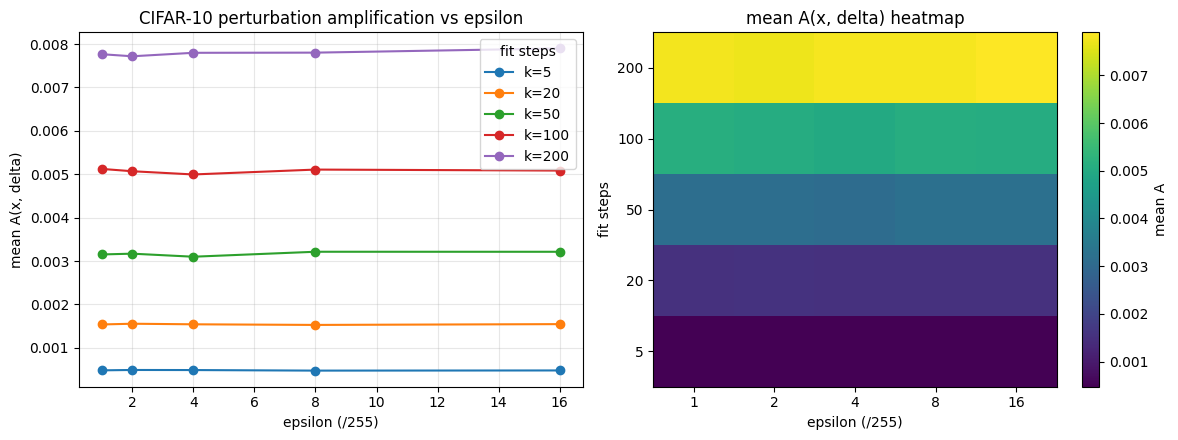

,fit_steps,eps_255,mean_A,median_A,std_A,mean_||delta_phi||_2,mean_mse_clean,mean_mse_pert
0,5,1.0,0.000483,0.000476,0.000026,0.000060,0.014943,0.014946
1,5,2.0,0.000491,0.000490,0.000027,0.000123,0.014943,0.014963
2,5,4.0,0.000489,0.000491,0.000025,0.000246,0.014943,0.015019
3,5,8.0,0.000476,0.000477,0.000014,0.000478,0.014943,0.015291
4,5,16.0,0.000480,0.000476,0.000023,0.000960,0.014943,0.016159
5,20,1.0,0.001540,0.001523,0.000061,0.000193,0.012911,0.012912
6,20,2.0,0.001557,0.001543,0.000074,0.000391,0.012911,0.012930
7,20,4.0,0.001543,0.001551,0.000083,0.000777,0.012911,0.012983
8,20,8.0,0.001529,0.001522,0.000069,0.001533,0.012911,0.013177
9,20,16.0,0.001547,0.001553,0.000066,0.003108,0.012911,0.014052


In [ ]:
# Plots for A(x, delta).
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for fit_steps, group in A_df.groupby("fit_steps"):
    group = group.sort_values("eps_255")
    axes[0].plot(group["eps_255"], group["mean_A"], marker="o", label=f"k={fit_steps}")
axes[0].set_xlabel("epsilon (/255)")
axes[0].set_ylabel("mean A(x, delta)")
axes[0].set_title("CIFAR-10 perturbation amplification vs epsilon")
axes[0].grid(alpha=0.3)
axes[0].legend(title="fit steps")

heat = A_df.pivot(index="fit_steps", columns="eps_255", values="mean_A")
im = axes[1].imshow(heat.values, aspect="auto", origin="lower")
axes[1].set_xticks(range(len(heat.columns)))
axes[1].set_xticklabels([f"{c:g}" for c in heat.columns])
axes[1].set_yticks(range(len(heat.index)))
axes[1].set_yticklabels([str(i) for i in heat.index])
axes[1].set_xlabel("epsilon (/255)")
axes[1].set_ylabel("fit steps")
axes[1].set_title("mean A(x, delta) heatmap")
fig.colorbar(im, ax=axes[1], label="mean A")

plt.tight_layout()
plt.show()

compact = A_df[["fit_steps", "eps_255", "mean_A", "median_A", "std_A", "mean_||delta_phi||_2", "mean_mse_clean", "mean_mse_pert"]]
display(compact)

In [ ]:
# ============================================================
# Fourier-feature Modulated SIREN: single-image CIFAR test
# ============================================================
#
# Goal:
#   Test whether Fourier-feature encoded coordinates help CIFAR reconstruction.
#
# This cell:
#   1. Builds Fourier features gamma(x,y)
#   2. Uses a SIREN-style modulated network on top of gamma(x,y)
#   3. Fits one CIFAR image by optimizing only phi
#   4. Prints PSNR/MSE at selected iterations
#   5. Visualizes original vs reconstructions
#
# It is intentionally notebook-local and does not modify the repo.

import math
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# Config
# -----------------------------

FOURIER_IMAGE_SEED = IMAGE_SEED   # same image as your previous SIREN test
FOURIER_RECON_ITERS = RECON_ITERS # e.g. [200, 500, 1000, 2000, 5000]
FOURIER_FIT_LR = FIT_LR           # usually 0.01

# Try these first.
FOURIER_NUM_FREQS = 64
FOURIER_SIGMA = 10.0

# Keep close to your current SIREN pipeline.
FOURIER_HIDDEN_DIM = 256
FOURIER_MOD_DIM = 512
FOURIER_DEPTH = 10
FOURIER_OUT_FEATURES = 3

# SIREN frequency inside hidden layers.
FOURIER_SIREN_FREQ = 30.0

# Set True to optimize network weights + phi for pure single-image capacity test.
# Set False to optimize only phi, which is closer to the functa/makeset setting.
FOURIER_OPTIMIZE_WEIGHTS_TOO = True

# If optimizing weights too, use a smaller network LR.
FOURIER_WEIGHT_LR = 1e-4
FOURIER_WEIGHT_LR = 3e-6
FOURIER_FIT_LR = 0.003

# -----------------------------
# Fourier feature encoder
# -----------------------------

class FourierFeatureEncoding(nn.Module):
    """
    Maps 2D coordinates to Fourier features:

        gamma(x) = [sin(2*pi*B*x), cos(2*pi*B*x)]

    Input:
        coords: (N, 2), usually in [-1, 1]

    Output:
        encoded: (N, 2*num_freqs)
    """
    def __init__(self, in_dim=2, num_freqs=64, sigma=10.0, device="cuda"):
        super().__init__()
        B = torch.randn(num_freqs, in_dim, device=device) * sigma
        self.register_buffer("B", B)

    @property
    def out_dim(self):
        return 2 * self.B.shape[0]

    def forward(self, coords):
        # coords: (N, 2)
        proj = 2.0 * math.pi * coords @ self.B.t()  # (N, num_freqs)
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)


# -----------------------------
# SIREN layer with modulation shift
# -----------------------------

class NotebookSineAffine(nn.Module):
    """
    Sine layer:

        y = sin(freq * (W x + b + shift))

    shift is produced from phi and has shape (hidden_dim,).
    """
    def __init__(self, in_features, out_features, freq=30.0, is_first=False):
        super().__init__()
        self.affine = nn.Linear(in_features, out_features)
        self.freq = freq
        self.is_first = is_first
        self.reset_parameters()

    def reset_parameters(self):
        with torch.no_grad():
            in_features = self.affine.in_features

            if self.is_first:
                # SIREN first-layer style init.
                bound = 1.0 / in_features
            else:
                # SIREN hidden-layer style init.
                bound = math.sqrt(6.0 / in_features) / self.freq

            self.affine.weight.uniform_(-bound, bound)
            self.affine.bias.uniform_(-bound, bound)

    def forward(self, x, shift=None):
        z = self.affine(x)
        if shift is not None:
            z = z + shift.view(1, -1)
        return torch.sin(self.freq * z)


class NotebookModulatedFourierSIREN(nn.Module):
    """
    Notebook-local model:

        coords -> Fourier features -> modulated SIREN -> RGB

    phi produces one shift vector per SIREN hidden layer.
    """
    def __init__(
        self,
        height=32,
        width=32,
        out_features=3,
        hidden_dim=256,
        mod_dim=512,
        depth=10,
        num_freqs=64,
        fourier_sigma=10.0,
        siren_freq=30.0,
        device="cuda",
    ):
        super().__init__()

        self.height = height
        self.width = width
        self.out_features = out_features
        self.hidden_features = hidden_dim
        self.modul_features = mod_dim
        self.depth = depth
        self.device = device

        self.encoder = FourierFeatureEncoding(
            in_dim=2,
            num_freqs=num_freqs,
            sigma=fourier_sigma,
            device=device,
        )

        layers = []
        in_dim = self.encoder.out_dim

        for layer_idx in range(depth):
            layers.append(
                NotebookSineAffine(
                    in_features=in_dim if layer_idx == 0 else hidden_dim,
                    out_features=hidden_dim,
                    freq=siren_freq,
                    is_first=(layer_idx == 0),
                )
            )

        self.net = nn.ModuleList(layers)
        self.hidden2rgb = nn.Linear(hidden_dim, out_features)

        # phi -> all per-layer shifts
        self.modul = nn.Linear(mod_dim, depth * hidden_dim)

        self.register_buffer("coords", self._make_coords(height, width, device))

    @staticmethod
    def _make_coords(height, width, device):
        # normalized coordinate grid in [-1, 1]
        ys = torch.linspace(-1.0, 1.0, height, device=device)
        xs = torch.linspace(-1.0, 1.0, width, device=device)

        # indexing="ij" avoids future warning if your PyTorch supports it.
        try:
            yy, xx = torch.meshgrid(ys, xs, indexing="ij")
        except TypeError:
            yy, xx = torch.meshgrid(ys, xs)

        coords = torch.stack([xx, yy], dim=-1).view(-1, 2)
        return coords

    def forward(self, phi):
        """
        phi: (mod_dim,)
        returns: (H*W, out_features)
        """
        x = self.encoder(self.coords)

        shifts = self.modul(phi).view(self.depth, self.hidden_features)

        for i, layer in enumerate(self.net):
            x = layer(x, shift=shifts[i])

        return self.hidden2rgb(x)


# -----------------------------
# Fit helper
# -----------------------------

def fit_phi_snapshots_fourier(
    model,
    image_chw,
    iter_checkpoints,
    phi_lr=0.01,
    weight_lr=1e-4,
    optimize_weights_too=True,
):
    checkpoints = sorted(set(int(x) for x in iter_checkpoints))
    max_iter = max(checkpoints)

    target = image_to_target(image_chw)

    phi = torch.zeros(model.modul_features, device=DEVICE, requires_grad=True)

    if optimize_weights_too:
        for p in model.parameters():
            p.requires_grad_(True)
        params = [
            {"params": [phi], "lr": phi_lr},
            {"params": model.parameters(), "lr": weight_lr},
        ]
        opt = optim.Adam(params)
    else:
        for p in model.parameters():
            p.requires_grad_(False)
        opt = optim.SGD([phi], lr=phi_lr)

    snapshots = {}

    model.train()

    for step in range(1, max_iter + 1):
        opt.zero_grad(set_to_none=True)

        fitted = model(phi)
        loss = ((fitted - target) ** 2).mean()

        loss.backward()
        opt.step()

        if step in checkpoints:
            with torch.no_grad():
                model.eval()
                fitted_post = model(phi).detach()
                mse = ((fitted_post - target) ** 2).mean()
                snapshots[step] = {
                    "phi": phi.detach().clone(),
                    "fitted_flat": fitted_post.detach().clone(),
                    "mse": float(mse.item()),
                    "psnr": float(psnr_from_mse(mse).item()),
                }
                model.train()

    model.eval()
    return snapshots


# -----------------------------
# Pick same image and fit
# -----------------------------

rng_ff = np.random.default_rng(FOURIER_IMAGE_SEED)
image_idx_ff = int(rng_ff.integers(0, len(dataset)))
image_ff, label_ff = get_dataset_item(image_idx_ff)

fourier_model = NotebookModulatedFourierSIREN(
    height=32,
    width=32,
    out_features=FOURIER_OUT_FEATURES,
    hidden_dim=FOURIER_HIDDEN_DIM,
    mod_dim=FOURIER_MOD_DIM,
    depth=FOURIER_DEPTH,
    num_freqs=FOURIER_NUM_FREQS,
    fourier_sigma=FOURIIER_SIGMA if "FOURIER_SIGMA" not in globals() else FOURIER_SIGMA,
    siren_freq=FOURIER_SIREN_FREQ,
    device=DEVICE,
).to(DEVICE)

print("Fourier-feature Modulated SIREN config:")
print("  image index          :", image_idx_ff)
print("  label                :", label_ff, CIFAR10_CLASSES[label_ff])
print("  hidden_dim           :", FOURIER_HIDDEN_DIM)
print("  mod_dim              :", FOURIER_MOD_DIM)
print("  depth                :", FOURIER_DEPTH)
print("  num_freqs            :", FOURIER_NUM_FREQS)
print("  fourier_sigma        :", FOURIER_SIGMA)
print("  siren_freq           :", FOURIER_SIREN_FREQ)
print("  optimize weights too :", FOURIER_OPTIMIZE_WEIGHTS_TOO)
print("  phi lr               :", FOURIER_FIT_LR)
print("  weight lr            :", FOURIER_WEIGHT_LR)
print()

snapshots_ff = fit_phi_snapshots_fourier(
    fourier_model,
    image_ff,
    FOURIER_RECON_ITERS,
    phi_lr=FOURIER_FIT_LR,
    weight_lr=FOURIER_WEIGHT_LR,
    optimize_weights_too=FOURIER_OPTIMIZE_WEIGHTS_TOO,
)


# -----------------------------
# Table
# -----------------------------

rows_ff = []
for it in sorted(snapshots_ff):
    rows_ff.append({
        "model": "fourier_modulated_siren",
        "dataset_index": image_idx_ff,
        "label": label_ff,
        "class_name": CIFAR10_CLASSES[label_ff],
        "iters": it,
        "mse": snapshots_ff[it]["mse"],
        "psnr": snapshots_ff[it]["psnr"],
    })

recon_df_ff = pd.DataFrame(rows_ff)
display(recon_df_ff)


# -----------------------------
# Plot
# -----------------------------

def target_to_image_fourier(target_flat, model):
    return (
        target_flat.detach()
        .view(model.height, model.width, model.out_features)
        .clamp(0, 1)
        .cpu()
        .numpy()
    )


n_cols_ff = len(FOURIER_RECON_ITERS) + 1
fig_ff, axes_ff = plt.subplots(1, n_cols_ff, figsize=(2.4 * n_cols_ff, 2.9))

show_cifar(
    axes_ff[0],
    image_ff,
    title=f"original\nidx={image_idx_ff}\ny={label_ff} {CIFAR10_CLASSES[label_ff]}",
)

for ax, it in zip(axes_ff[1:], sorted(snapshots_ff)):
    recon_ff = target_to_image_fourier(snapshots_ff[it]["fitted_flat"], fourier_model)
    ax.imshow(recon_ff)
    ax.set_title(f"iters={it}\nPSNR={snapshots_ff[it]['psnr']:.2f} dB")
    ax.axis("off")

fig_ff.suptitle(
    "CIFAR-10 reconstruction: Fourier-feature Modulated SIREN"
)
plt.tight_layout()
plt.show()

Fourier-feature Modulated SIREN config:
  image index          : 8138
  label                : 1 automobile
  hidden_dim           : 256
  mod_dim              : 512
  depth                : 10
  num_freqs            : 64
  fourier_sigma        : 10.0
  siren_freq           : 30.0
  optimize weights too : True
  phi lr               : 0.01
  weight lr            : 3e-06



KeyboardInterrupt: 